**Data Collection & Loading**

This cell loads two datasets:

Netflix dataset (Kaggle): 8,807 titles with features like type, title, country, date_added, and release_year.

World Bank GDP dataset: Annual global GDP growth rate (%) from 2008 to 2021.

Both datasets are extracted from zip files and loaded into pandas DataFrames.

In [4]:
import zipfile
import pandas as pd

# open  GDP zip
with zipfile.ZipFile("API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_175549.zip", "r") as z:
    z.extractall()

# downlowd
netflix = pd.read_csv("netflix_titles.csv")
gdp = pd.read_csv("API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_175549.csv", skiprows=4)

print("Netflix shape:", netflix.shape)
print("Netflix columns:", netflix.columns.tolist())
print()
print("GDP shape:", gdp.shape)
print("GDP columns:", gdp.columns.tolist()[:10])

Netflix shape: (8807, 12)
Netflix columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

GDP shape: (266, 71)
GDP columns: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965']


**Netflix – Basic Statistics**

A quick overview of the Netflix dataset: missing values per column, content type distribution (Movie vs TV Show), release year range, and a sample of the date_added column.

In [6]:
# Netflix - basic statistics
print("=== NETFLIX ===")
print(netflix.isnull().sum())
print()
print("Type distribution:")
print(netflix["type"].value_counts())
print()
print("Year range:", netflix["release_year"].min(), "-", netflix["release_year"].max())
print()
print("date_added sample:", netflix["date_added"].dropna().head(3).tolist())

=== NETFLIX ===
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Type distribution:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Year range: 1925 - 2021

date_added sample: ['September 25, 2021', 'September 24, 2021', 'September 24, 2021']


**Netflix EDA**

Checking for missing values, content type distribution (Movie vs TV Show), and how many titles were added each year between 2008–2021.

Results are plotted as a line chart.

Content added per year:
year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


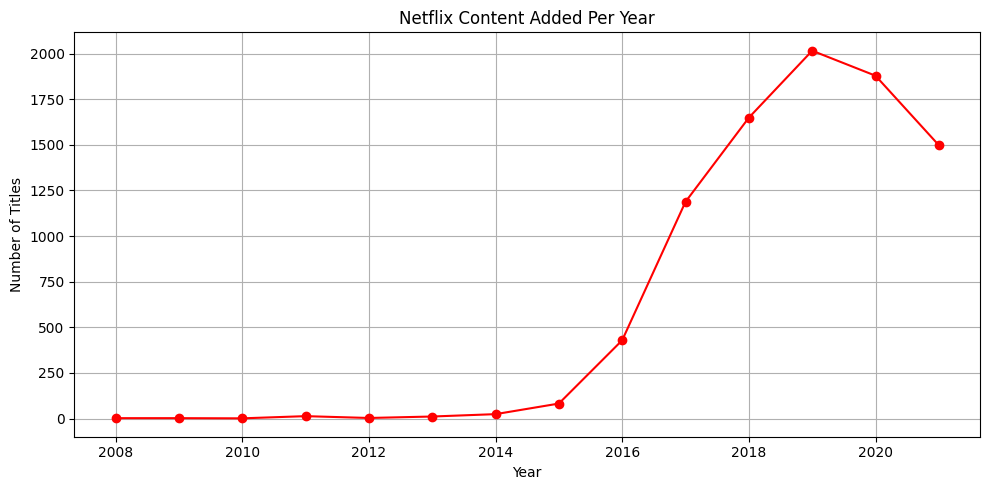

In [7]:
import matplotlib.pyplot as plt

# Convert date_added to datetime and extract year
netflix["date_added"] = pd.to_datetime(netflix["date_added"].str.strip(), errors="coerce")
netflix["year_added"] = netflix["date_added"].dt.year

# Count content added per year (2008-2021 to match GDP)
content_per_year = netflix[netflix["year_added"].between(2008, 2021)]["year_added"].value_counts().sort_index()
print("Content added per year:")
print(content_per_year)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(content_per_year.index, content_per_year.values, marker="o", color="red")
plt.title("Netflix Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.tight_layout()
plt.show()

**GDP EDA**

Extracts the global GDP growth rate from the World Bank dataset and plots it over time (2008–2021).

The dashed line marks 0% growth — dips below it indicate economic downturns (2009 financial crisis, 2020 COVID-19).

GDP data (2008-2021):
  year  gdp_growth
2008.0    2.092395
2009.0   -1.318649
2010.0    4.524240
2011.0    3.339003
2012.0    2.731210
2013.0    2.888142
2014.0    3.133017
2015.0    3.113789
2016.0    2.793592
2017.0    3.451830
2018.0    3.273958
2019.0    2.679118
2020.0   -2.899223
2021.0    6.413350


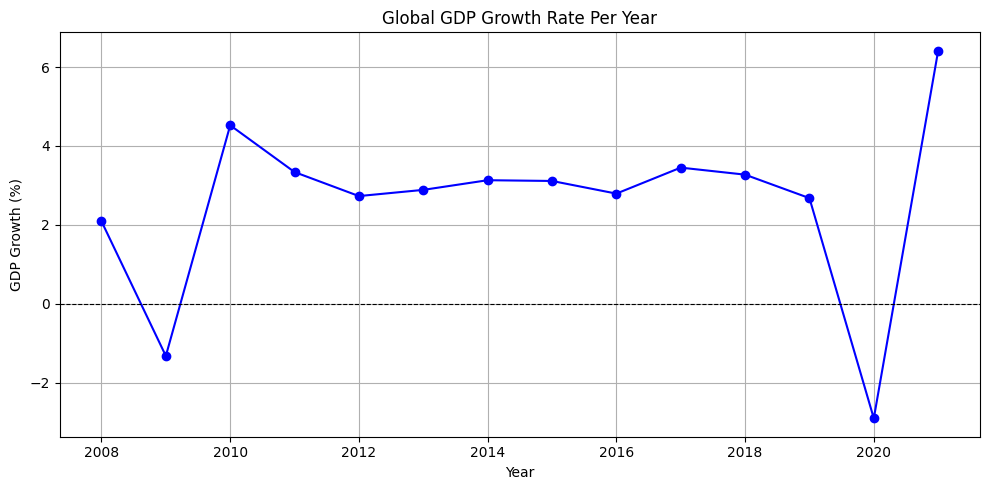

**Merging Datasets & Visualization**

Merges the Netflix content count and global GDP growth rate by year.

Plots both on a dual-axis chart to visually compare Netflix growth and economic trends between 2008–2021.

  year  titles_added  gdp_growth
2008.0             2    2.092395
2009.0             2   -1.318649
2010.0             1    4.524240
2011.0            13    3.339003
2012.0             3    2.731210
2013.0            11    2.888142
2014.0            24    3.133017
2015.0            82    3.113789
2016.0           429    2.793592
2017.0          1188    3.451830
2018.0          1649    3.273958
2019.0          2016    2.679118
2020.0          1879   -2.899223
2021.0          1498    6.413350


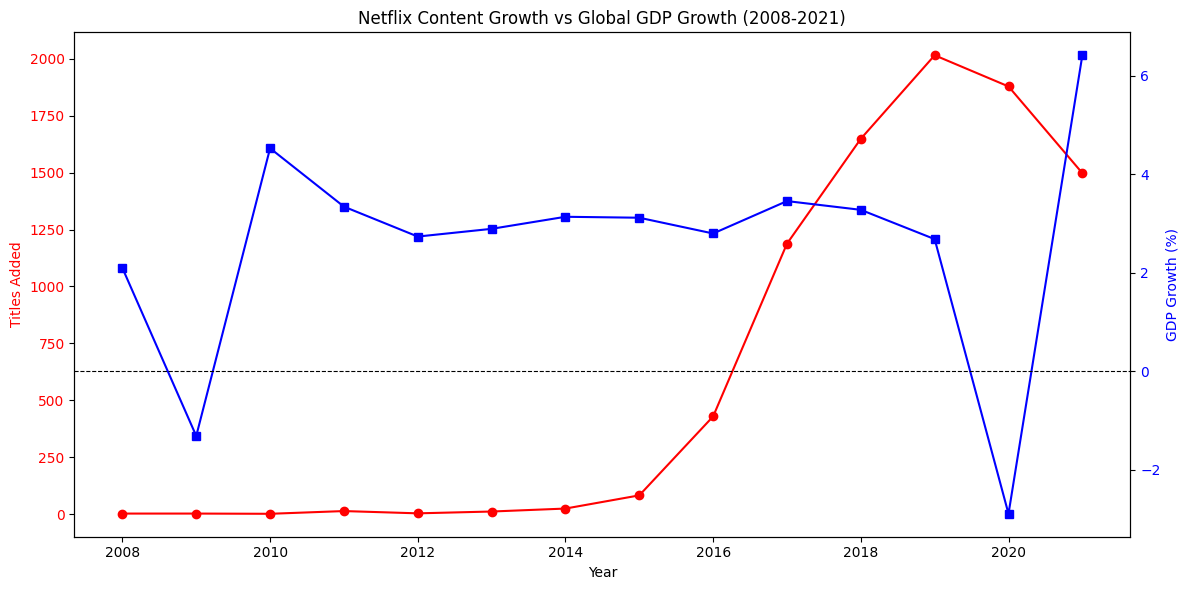

In [9]:
# Merge datasets
content_df = content_per_year.reset_index()
content_df.columns = ["year", "titles_added"]
content_df["year"] = content_df["year"].astype(float)

merged = pd.merge(content_df, gdp_long[["year", "gdp_growth"]], on="year")
print(merged.to_string(index=False))

# Plot both together
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel("Year")
ax1.set_ylabel("Titles Added", color="red")
ax1.plot(merged["year"], merged["titles_added"], marker="o", color="red", label="Netflix Titles")
ax1.tick_params(axis="y", labelcolor="red")

ax2 = ax1.twinx()
ax2.set_ylabel("GDP Growth (%)", color="blue")
ax2.plot(merged["year"], merged["gdp_growth"], marker="s", color="blue", label="GDP Growth")
ax2.tick_params(axis="y", labelcolor="blue")
ax2.axhline(0, color="black", linestyle="--", linewidth=0.8)

plt.title("Netflix Content Growth vs Global GDP Growth (2008-2021)")
fig.tight_layout()
plt.show()

**Hypothesis Testing**

Two hypothesis tests to investigate whether economic downturns affect Netflix's content strategy:

Test 1 – Pearson Correlation: Tests whether there is a statistically significant linear relationship between global GDP growth rate and the number of titles Netflix adds each year.

Test 2 – Independent T-test: Compares the average number of titles added during economic downturn years (GDP < 0) versus normal years. Downturn years in this dataset are 2009 and 2020.

Both tests use a significance level of 0.05.

In [10]:
from scipy import stats

# Hypothesis Test 1: Correlation between GDP growth and titles added
correlation, p_value = stats.pearsonr(merged["gdp_growth"], merged["titles_added"])

print("=== Hypothesis Test 1 ===")
print("H0: There is NO correlation between GDP growth and Netflix content added")
print("Ha: There IS a correlation between GDP growth and Netflix content added")
print()
print(f"Pearson Correlation: {correlation:.4f}")
print(f"P-value:             {p_value:.4f}")
print()
if p_value < 0.05:
    print("Result: REJECT H0 - significant correlation found")
else:
    print("Result: FAIL TO REJECT H0 - no significant correlation")

print()
print("=== Hypothesis Test 2 ===")
print("H0: Netflix adds the same amount of content during downturns vs normal years")
print("Ha: Netflix adds MORE content during economic downturns")
print()

# Define downturn years (GDP < 0)
downturn = merged[merged["gdp_growth"] < 0]["titles_added"]
normal = merged[merged["gdp_growth"] >= 0]["titles_added"]

print(f"Downturn years (GDP < 0): {merged[merged['gdp_growth'] < 0]['year'].tolist()}")
print(f"Average titles in downturn years: {downturn.mean():.1f}")
print(f"Average titles in normal years:   {normal.mean():.1f}")
print()

t_stat, p_val2 = stats.ttest_ind(downturn, normal)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_val2:.4f}")
print()
if p_val2 < 0.05:
    print("Result: REJECT H0 - Netflix significantly increases content during downturns")
else:
    print("Result: FAIL TO REJECT H0 - no significant difference found")

=== Hypothesis Test 1 ===
H0: There is NO correlation between GDP growth and Netflix content added
Ha: There IS a correlation between GDP growth and Netflix content added

Pearson Correlation: -0.0867
P-value:             0.7682

Result: FAIL TO REJECT H0 - no significant correlation

=== Hypothesis Test 2 ===
H0: Netflix adds the same amount of content during downturns vs normal years
Ha: Netflix adds MORE content during economic downturns

Downturn years (GDP < 0): [2009.0, 2020.0]
Average titles in downturn years: 940.5
Average titles in normal years:   576.3

T-statistic: 0.5697
P-value:     0.5794

Result: FAIL TO REJECT H0 - no significant difference found


**Scatter Plot** – GDP Growth vs Titles Added

Plots each year as a point, with GDP growth rate on the x-axis and number of Netflix titles added on the y-axis. Each point is labeled with its year.

Visually confirms the lack of a clear linear relationship between the two variables.

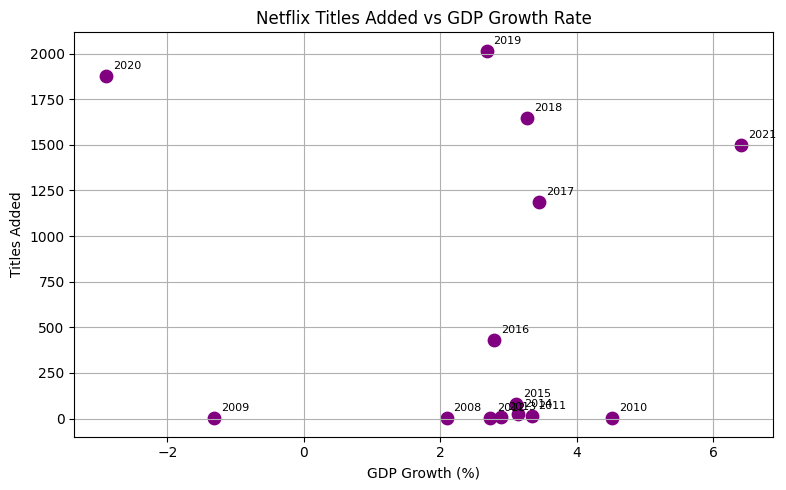

In [11]:
# Scatter plot: GDP growth vs titles added
plt.figure(figsize=(8, 5))
plt.scatter(merged["gdp_growth"], merged["titles_added"], color="purple", s=80)

for _, row in merged.iterrows():
    plt.annotate(int(row["year"]), (row["gdp_growth"], row["titles_added"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.xlabel("GDP Growth (%)")
plt.ylabel("Titles Added")
plt.title("Netflix Titles Added vs GDP Growth Rate")
plt.grid(True)
plt.tight_layout()
plt.show()